# <span style="color:red"> **LSN - Esercitazione 09**
### <span style="color:green"> 15.05.2025
#### <span style="color:green"> Lucrezia Bioni (13655A)

Note:
- poiché, per poterla usare nel sort, ho dovuto definire calculate_length come constant, non modifica effettivamente il data membro _length, e quindi ho necessità di ricalcolarla ogni volta. capire se c'è un modo per evitare questa cosa.
- capire come mai se uso norma L1 le cose funzionano, mentre se uso L2 no.

### <span style="color:blue">**_Algoritmo Genetico_**

Il **Problema del Commesso Viaggiatore (TSP)** consiste nel trovare il percorso ottimale per visitare N città (con posizioni $\vec{c}_i$) una sola volta, ritornando al punto di partenza, minimizzando la distanza totale. Ogni percorso è rappresentato da una permutazione P delle città: $[ \vec{c}_{P1}, \vec{c}_{P2}, ..., \vec{c}_{PN} ]$, dove l'ordine degli elementi indica la sequenza di visita. Ad esempio, per 5 città un possibile percorso è $[1, 3, 5, 4, 2]$. La qualità del percorso si può valutare con due funzioni costo principali: $L^{(1)} = \sum_{i=1}^N |\vec{x}_i - \vec{x}_{i+1}|$ e $L^{(2)} = \sum_{i=1}^N |\vec{x}_i - \vec{x}_{i+1}|^2$, dove $\vec{x}_{N+1} = \vec{x}_1$. L'obiettivo è trovare la permutazione P che minimizza una di queste funzioni, combinando opportunamente scambi tra coppie di città. Per risolvere il TSP si possono usare algoritmi genetici, simulated annealing o altre tecniche di ottimizzazione. 

In questa esercitazione, si è risolto il TSP con un **Algoritmo Genetico**, ovvero un algoritmo metaeuristico che simula il meccanismo di evoluzione della specie per selezionare l'individuo che meglio soddisfi la richiesta del problema. L'algoritmo, in particolare, parte da una popolazione di $npop$ individui generata randomicamente, calcola la bontà (fitness) rispetto alla richiesta del problema di ciascun elemento della popolazione e genera $npop$ figli con il seguente schema: seleziona una coppia di genitori (ad esempio secondo uno specifico algoritmo di selezione), mischia la coppia scegliendo un punto di crossover a formare due figli, e muta ciascun figlio con una certà probabilità di mutazione $pmut$. A questo punto, l'algoritmo sostituisce la popolazione corrente con la nuova popolazione, e ripete il processo per un numero $ngen$ di volte.

L'esercizio è stato svolto per $34$ città disposte randomicamente su una circonferenza e dentro un quadrato unitari. Si è scelto di strutturare il codice in classi:

**Classe `Route`** 

Rappresenta un singolo percorso (individuo) e contiene come variabili membro:
- `_ndim`: Numero di città (default $=34$)
- `_route`: Vettore con l'ordine di visita delle città
- `_length`: Lunghezza totale del percorso
- `_point_rnd`: Puntatore a generatore numeri casuali
- `_pmut`: Probabilità complessiva di mutazione ($=0.1$)

Contiene, inoltre, i seguenti metodi:
- Creazione di una popolazione iniziale: genera percorsi casuali con `initialize()` e calcola lunghezze con `calculate_length`
- Operatori di mutazione raccolti nel metodo `mutate()`, che applica una mutazione con probabilità `_pmut`:
  * `swap()`: Scambia due città.
  * `shift()`: Sposta un blocco di città in una nuova posizione.
  * `swap_block()`: Scambia due blocchi disgiunti.
  * `invert_block()`: Inverte l'ordine delle città tra due indici. \
  Ciascuna di queste mutazioni è equiprobabile, e ha una probabilità assoluta di avvenire pari al $2.5 \%$.
- Metodo di validazione (`check()`) che controlla che tutti i percorsi abbiano la prima città fissa, e che ciascuno visiti ciascuna città una sola volta.
- Funzione per verificare che vengano rispettate le condizioni periodiche al contorno `pbc()`

**Classe `Population`** 

Rappresenta una popolazione di soluzioni (percorsi) costituite da oggetti di tipo `Route`.

Tra le variabili membro, include:

- Un generatore di numeri casuali `Random`
- Il numero di individui `_npop` e il numero di generazioni `_ngen`
- La matrice delle distanze `_dist_matrix`
- Un campo (`arma::field<Route>`) contenente la popolazione `_pop`
- Parametri come:
  - `_selexp`: esponente della selezione (favorisce gli individui migliori)
  - `_pcross`: probabilità di crossover

Presenta, inoltre, i seguenti metodi principali:
- `initialize_pop(int npop, int ngen, arma::mat *dist_matrix)`: inizializza la popolazione, costruendo `_npop` percorsi iniziali con la matrice delle distanze
- `get_percorso(int i)`: restituisce l’individuo `i`-esimo della popolazione.
- `select_index()` e `select()`: implementano il meccanismo di selezione: la selezione è stocastica ma orientata, favorendo percorsi più brevi, e segue l'algoritmo: l'indice j dell'individuo selezionato è dato da $j= int(M \times r^p)+1$, dove $r$ è un numero casuale uniformemente distribuito $r\in[0,1)$, e $p$ è un opportuno esponente. Poiché si è scelto di ordinare la popolazione ponendo i migliori individui all'inizio del vettore, si è scelto `_selexp` $=2.0$, così da rendere più probabili i numeri bassi.
- `sort_by_length()`: ordina la popolazione secondo la lunghezza del percorso (fitness).
- `crossover(Route a, Route b)`: applica un operatore di crossover parziale ordinato, che viene eseguito con probabilità `_pcross`. In particolare, si scelgono due punti di taglio; da ciascun genitore, si genera un figlio che mantiene invariato il segmento tra i due tagli, e che ha le restanti città nell'ordine in cui compaiono nell'altro genitore.
- `evolve(const arma::mat dist_matrix)`: esegue l'evoluzione della popolazione per `_ngen` generazioni:
    1. Ordina la popolazione
    2. Seleziona genitori e genera figli con crossover
    3. Applica mutazioni (tramite `Route::mutate()`)
    4. Aggiorna la popolazione e calcola statistiche:
       * Lunghezza del miglior percorso
       * Lunghezza media dei migliori N/2

I risultati vengono salvati su file:
- `results.dat`: andamento delle lunghezze nel tempo
- `best_route.dat`: miglior percorso finale

**`Main`**

I have used a population of 200 members and 300 generations. I have used a selection operator with p=2 (because I have put the best paths at the beginning of the sorted field of possible routes). \
Osservo che più alzo la probabilità di una mutazione, più diventa rumoroso il valore medio dei migliori cammini a ogni generazione. Ho dunque scelto di tenere probabilità di avere una mutazione a 10%, e ciascuna mutazione al 2,5%. \
Poiché le città non sono distribuite in modo uniforme, e spesso sono molto ravvicinate, ho preferito calcolare le distanze con la norma L1. L2, infatti, dà grande peso a punti molto distanzi, e questo può portare a convergere troppo velocemente a una soluzione non realmente ottimale.

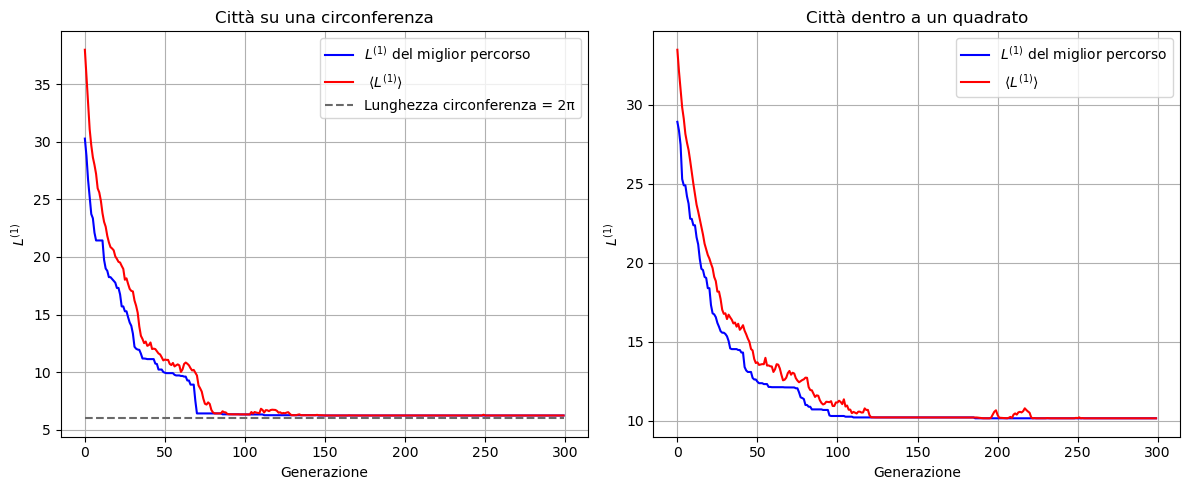

In [103]:
import matplotlib.pyplot as plt
import numpy as np
from math import pi

generation_c, L2_c, L2_mean_c = np.loadtxt("./simulazioni-eseguite/circumference/results.dat", unpack=True, usecols=(0,1,2), dtype=str)
generation_s, L2_s, L2_mean_s = np.loadtxt("./simulazioni-eseguite/square/results.dat", unpack=True, usecols=(0,1,2), dtype=str)
generation_c = generation_c.astype(int)
generation_s = generation_s.astype(int)
L2_c = L2_c.astype(float)
L2_s = L2_s.astype(float)
L2_mean_c = L2_mean_c.astype(float)
L2_mean_s = L2_mean_s.astype(float)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

ax1.plot(generation_c, L2_c, label=r"$L^{(1)}$ del miglior percorso", color='blue')
ax1.plot(generation_c, L2_mean_c, label=r" $\langle L^{(1)}\rangle$", color='red')
ax1.plot(generation_c, np.full_like(generation_c, 2 * pi), color='dimgray', linestyle='--' ,label='Lunghezza circonferenza = 2π')
ax1.set_title("Città su una circonferenza")
ax1.set_xlabel('Generazione')
ax1.set_ylabel(r"$L^{(1)}$")
ax1.grid(True)
ax1.legend()

#nel secondo grafico plotterò città quadrate
ax2.plot(generation_s, L2_s, label=r"$L^{(1)}$ del miglior percorso", color='blue')
ax2.plot(generation_s, L2_mean_s, 'r-', label=r" $\langle L^{(1)}\rangle$")
ax2.set_title("Città dentro a un quadrato")
ax2.set_xlabel('Generazione')
ax2.set_ylabel(r"$L^{(1)}$")
ax2.grid(True)
ax2.legend()

# Margini stretti e layout ordinato
plt.tight_layout()
plt.show()


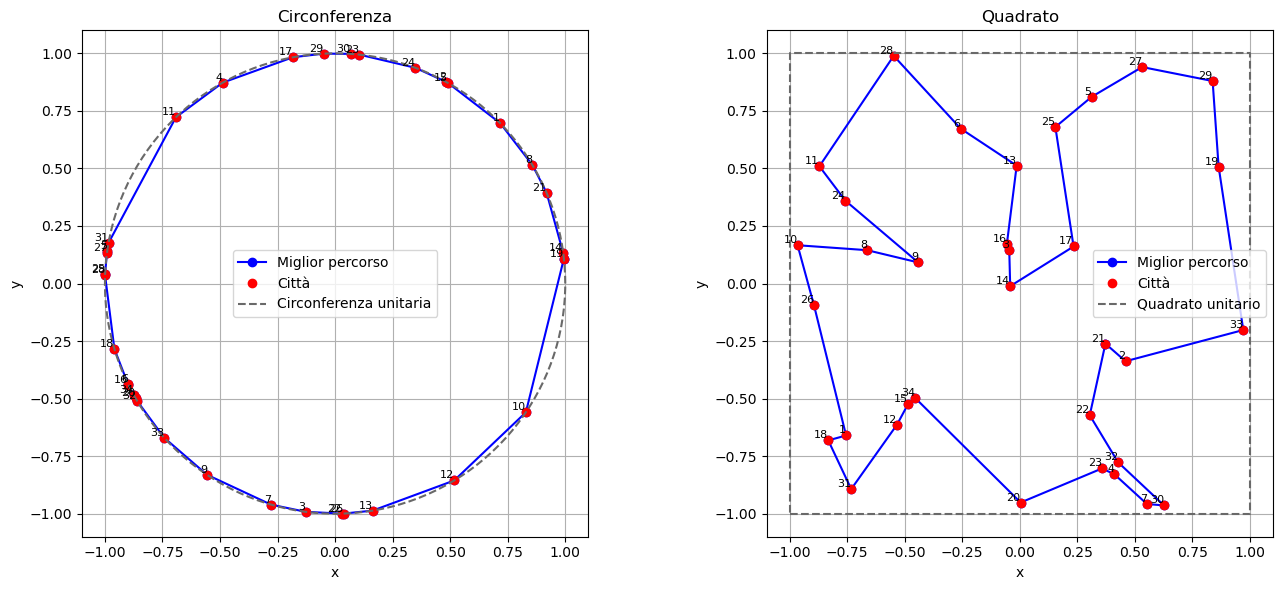

In [101]:
import matplotlib.pyplot as plt
import numpy as np

def load_and_plot(ax, cities_file, route_file, title):
    name_cities, x, y = np.loadtxt(cities_file, unpack=True, usecols=(0,1,2), dtype=str)
    x = x.astype(float)
    y = y.astype(float)

    best_route = np.loadtxt(route_file, dtype=str)
    n_cities = len(best_route)
    best_route_coord = np.zeros((2, n_cities + 1))  # +1 per chiudere il percorso

    for i in range(n_cities):
        city_name = best_route[i]
        index = np.where(name_cities == city_name)[0][0]
        best_route_coord[0, i] = x[index]
        best_route_coord[1, i] = y[index]

    # Chiudi il percorso collegando l'ultimo punto al primo
    best_route_coord[:, -1] = best_route_coord[:, 0]

    ax.plot(best_route_coord[0], best_route_coord[1], 'o-', label='Miglior percorso', color='blue')
    ax.plot(x, y, 'o', label='Città', color='red')

    for i in range(len(name_cities)):
        ax.text(x[i], y[i], name_cities[i], fontsize=8, ha='right', va='bottom')

    if "circumference" in cities_file:
        theta = np.linspace(0, 2*np.pi, 300)
        ax.plot(np.cos(theta), np.sin(theta), color='dimgray', linestyle='--', label='Circonferenza unitaria')
    elif "square" in cities_file:
        square_x = [-1, 1, 1, -1, -1]
        square_y = [-1, -1, 1, 1, -1]
        ax.plot(square_x, square_y, color='dimgray', linestyle='--', label='Quadrato unitario')

    ax.set_aspect('equal')
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

load_and_plot(ax1,"./simulazioni-eseguite/circumference/cities.dat","./simulazioni-eseguite/circumference/best_route.dat","Circonferenza")
load_and_plot(ax2,"./simulazioni-eseguite/square/cities.dat","./simulazioni-eseguite/square/best_route.dat","Quadrato")

plt.tight_layout()
plt.show()
